In [1]:
!pip install transformers datasets scikit-learn

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
import torch
from datasets import Dataset
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 15.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system =

##Download & Load Dataset (KaggleHub)

In [2]:
import kagglehub
import pandas as pd
import os
# Download latest version
path = kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products")

print("Path to dataset files:", path)




# List all files in the directory
for file in os.listdir(path):
    print(file)
df1 = pd.read_csv(os.path.join(path, "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv"))
df2 = pd.read_csv(os.path.join(path, "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv"))


Path to dataset files: /kaggle/input/consumer-reviews-of-amazon-products
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv
1429_1.csv
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv


###check the column in both data set

In [3]:
print("df1 columns:", df1.columns)
print("df2 columns:", df2.columns)
df2.shape

df1 columns: Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateAdded',
       'reviews.dateSeen', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs'],
      dtype='object')
df2 columns: Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs'],
      dtype='object')


(28332, 24)

##Merge & Clean Dataset

In [4]:
# 1. Keep only the necessary columns from both datasets
cols_to_keep = ['reviews.text', 'reviews.rating']
df1_clean = df1[cols_to_keep].copy()
df2_clean = df2[cols_to_keep].copy()

# 2. Combine both datasets
df = pd.concat([df1_clean, df2_clean], ignore_index=True)

# 3. Drop rows where either text or rating is missing
df.dropna(subset=['reviews.text', 'reviews.rating'], inplace=True)

# 4. Rename columns for simpler access
df.rename(columns={'reviews.text': 'text', 'reviews.rating': 'rating'}, inplace=True)

#df.drop_duplicates(subset=['text', 'rating'], inplace=True)

# 6. Print final shape and preview
print("Final dataset shape:", df.shape)
df.head()



Final dataset shape: (33332, 2)


,text,rating
0,I thought it would be as big as small paper bu...,3
1,This kindle is light and easy to use especiall...,5
2,Didnt know how much i'd use a kindle so went f...,4
3,I am 100 happy with my purchase. I caught it o...,5
4,Solid entry level Kindle. Great for kids. Gift...,5


##Map Star Ratings to Sentiment Classes

In [5]:
# Step 1: Map star ratings to sentiment labels
def map_sentiment(rating):
    if rating in [1, 2]:
        return 0  # Negative
    elif rating == 3:
        return 1  # Neutral
    else:
        return 2  # Positive
df['label'] = df['rating'].apply(map_sentiment)
df = df[['text', 'label']].reset_index(drop=True)

print(df['label'].value_counts(normalize=True) * 100)
df.head()

label
2    90.696628
0     5.094204
1     4.209168
Name: proportion, dtype: float64


,text,label
0,I thought it would be as big as small paper bu...,1
1,This kindle is light and easy to use especiall...,2
2,Didnt know how much i'd use a kindle so went f...,2
3,I am 100 happy with my purchase. I caught it o...,2
4,Solid entry level Kindle. Great for kids. Gift...,2


##💣 Exploratory Data Analysis (EDA)

<ipython-input-6-7b73faecd99b>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['label'], palette='pastel')


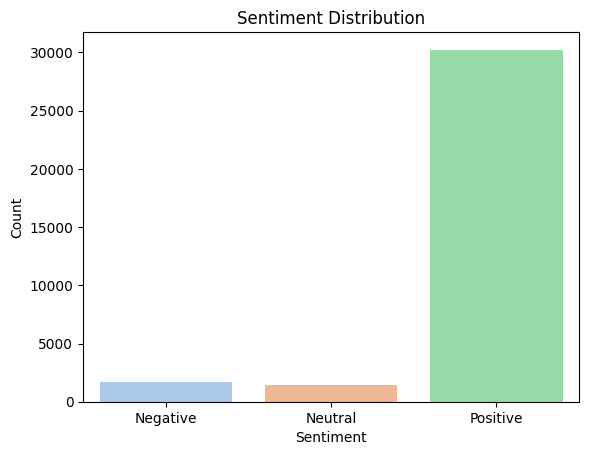

label
2    90.70%
0     5.09%
1     4.21%
Name: proportion, dtype: object


In [6]:

# Class distribution visualization
label_names = ['Negative', 'Neutral', 'Positive']

sns.countplot(x=df['label'], palette='pastel')
plt.xticks([0, 1, 2], label_names)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# Print class distribution (percentage)
print(df['label'].value_counts(normalize=True).map(lambda x: f"{x:.2%}"))


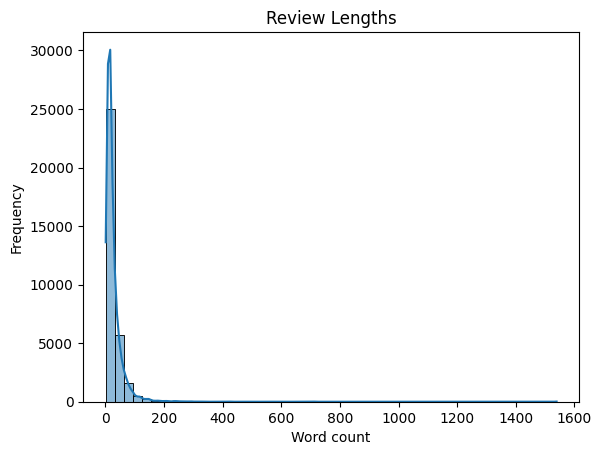

In [7]:

# Text length distribution
df['text_length'] = df['text'].apply(lambda x: len(x.split()))
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title('Review Lengths')
plt.xlabel('Word count')
plt.ylabel('Frequency')
plt.show()

In [8]:
# Check class distribution
print(df['label'].value_counts())


label
2    30231
0     1698
1     1403
Name: count, dtype: int64


#📊balancing the dataset  by using :


*   Down sampling
*   Data augmentation






In [9]:
from sklearn.utils import resample

df_positive = df[df['label'] == 2]
df_negative = df[df['label'] == 0]
df_neutral  = df[df['label'] == 1]

# Downsample positive class
df_positive_downsampled = resample(df_positive,
                                   replace=False,
                                   n_samples=8000,
                                   random_state=42)

# Combine all together
df_balanced = pd.concat([df_positive_downsampled, df_negative, df_neutral])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Check class distribution
print(df_balanced['label'].value_counts())



label
2    8000
0    1698
1    1403
Name: count, dtype: int64


In [10]:
# 🔄 Step 1: Imports and Setup
import nltk
from nltk.corpus import wordnet
from itertools import chain
import random


nltk.download('wordnet')
nltk.download('omw-1.4')

# 🔁 Step 2: Synonym Replacement Function
def synonym_replacement(text, n=2):
    words = text.split()
    new_words = words.copy()
    random_word_list = list(set([word for word in words if wordnet.synsets(word)]))
    random.shuffle(random_word_list)

    num_replaced = 0
    for random_word in random_word_list:
        synonyms = wordnet.synsets(random_word)
        if not synonyms:
            continue
        synonym_words = list(set(chain.from_iterable([word.lemma_names() for word in synonyms])))
        synonym_words = [w.replace('_', ' ') for w in synonym_words if w != random_word]
        if synonym_words:
            synonym = random.choice(synonym_words)
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break

    return ' '.join(new_words)

# 🧪 Step 3: Apply to NEUTRAL samples only

augmented = []

# Neutral and negative class augmentation
for i, row in df_balanced.iterrows():
    if row['label'] in [0, 1]:  # 0 = negative, 1 = neutral
        new_text = synonym_replacement(row['text'], n=2)
        augmented.append({'text': new_text, 'label': row['label']})

# Create augmented DataFrame
aug_df = pd.DataFrame(augmented)

# Combine original + augmented and shuffle
augmented_df = pd.concat([df_balanced, aug_df]).sample(frac=1).reset_index(drop=True)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [11]:
print(augmented_df.columns)  # sanity check
print(augmented_df['label'].value_counts())


Index(['text', 'label', 'text_length'], dtype='object')
label
2    8000
0    3396
1    2806
Name: count, dtype: int64


<ipython-input-12-865a59bd594f>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=augmented_df, palette='pastel')


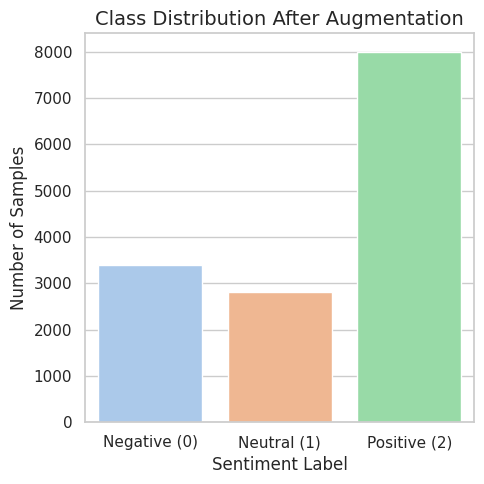

In [12]:

# Set the plot style
sns.set(style="whitegrid")

# Plot the count of each label
plt.figure(figsize=(5, 5))
sns.countplot(x='label', data=augmented_df, palette='pastel')

# Customize labels
plt.title('Class Distribution After Augmentation', fontsize=14)
plt.xlabel('Sentiment Label', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks([0, 1, 2], ['Negative (0)', 'Neutral (1)', 'Positive (2)'])
plt.tight_layout()

# Show plot
plt.show()


##load model and tokenizer

In [13]:
#spliting
df_train, df_val = train_test_split(augmented_df, test_size=0.2,
                                     stratify=augmented_df['label'],
                                     random_state=42)

print(f"Training set shape: {df_train.shape}")
print(f"Validation set shape: {df_val.shape}")

Training set shape: (11361, 3)
Validation set shape: (2841, 3)


In [14]:
# Step 8: Load model and tokenizer

model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:

# Step 9: Convert to Hugging Face datasets
train_dataset = Dataset.from_pandas(df_train)
val_dataset = Dataset.from_pandas(df_val)

# Define function to tokenize the datasets
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Convert pandas DataFrame to Hugging Face Dataset
train_dataset = Dataset.from_pandas(df_train)
val_dataset = Dataset.from_pandas(df_val)

In [16]:
# Tokenize the datasets
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/11361 [00:00<?, ? examples/s]

Map:   0%|          | 0/2841 [00:00<?, ? examples/s]

#train the model

In [19]:
from transformers import EarlyStoppingCallback
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Step 10: Define metrics computation
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    # Calculate metrics
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)

    # Calculate per-class metrics
    class_precision, class_recall, class_f1, _ = precision_recall_fscore_support(labels, preds, average=None)

    results = {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
    }

    # Add per-class metrics
    class_names = ['negative', 'neutral', 'positive']
    for i, name in enumerate(class_names):
        results[f'{name}_precision'] = class_precision[i]
        results[f'{name}_recall'] = class_recall[i]
        results[f'{name}_f1'] = class_f1[i]

    return results
# Define training arguments
training_args = TrainingArguments(
    output_dir="./roberta_sentiment_results",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,  # Use mixed precision training
)

# Create the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# Fine-tune the model
trainer.train()



/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-19-1e0e98165604>:49: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nourx202 (nourx202-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Negative Precision,Negative Recall,Negative F1,Neutral Precision,Neutral Recall,Neutral F1,Positive Precision,Positive Recall,Positive F1
1,0.392700,0.372225,0.869060,0.863876,0.863194,0.869060,0.836820,0.882353,0.858984,0.747748,0.591800,0.660697,0.914881,0.960625,0.937195
2,0.186500,0.363956,0.902147,0.900148,0.900264,0.902147,0.924031,0.876471,0.899623,0.822709,0.736185,0.777046,0.917355,0.971250,0.943534
3,0.219400,0.233104,0.933474,0.933327,0.933424,0.933474,0.909348,0.944118,0.926407,0.871324,0.844920,0.857919,0.965431,0.960000,0.962708
4,0.041500,0.303506,0.942274,0.942364,0.942775,0.942274,0.914326,0.957353,0.935345,0.879279,0.869875,0.874552,0.977128,0.961250,0.969124
5,0.128500,0.303082,0.945090,0.945098,0.945139,0.945090,0.931884,0.945588,0.938686,0.885305,0.880570,0.882931,0.971751,0.967500,0.969621
6,0.189300,0.301387,0.946850,0.947330,0.948283,0.946850,0.959276,0.935294,0.947133,0.857860,0.914439,0.885246,0.975316,0.963125,0.969182
7,0.002300,0.327824,0.949314,0.950019,0.951510,0.949314,0.956909,0.947059,0.951959,0.850575,0.923351,0.885470,0.984606,0.959375,0.971827
8,0.046600,0.327319,0.951074,0.951161,0.951283,0.951074,0.958333,0.947059,0.952663,0.884007,0.896613,0.890265,0.971875,0.971875,0.971875
9,0.000100,0.360169,0.950722,0.950528,0.950590,0.950722,0.931624,0.961765,0.946454,0.914657,0.878788,0.896364,0.971250,0.971250,0.971250
10,0.008500,0.353910,0.953889,0.953973,0.954142,0.953889,0.941007,0.961765,0.951273,0.900533,0.903743,0.902135,0.978522,0.968125,0.973296


TrainOutput(global_step=7110, training_loss=0.15095491927279533, metrics={'train_runtime': 782.2248, 'train_samples_per_second': 145.24, 'train_steps_per_second': 9.089, 'total_flos': 7473078847019520.0, 'train_loss': 0.15095491927279533, 'epoch': 10.0})

#Evaluation

In [20]:
# Evaluate the model
eval_results = trainer.evaluate()
print(f"Evaluation results: {eval_results}")


Evaluation results: {'eval_loss': 0.3539096713066101, 'eval_accuracy': 0.9538894755367828, 'eval_f1': 0.9539726618074861, 'eval_precision': 0.9541424487384803, 'eval_recall': 0.9538894755367828, 'eval_negative_precision': 0.9410071942446043, 'eval_negative_recall': 0.961764705882353, 'eval_negative_f1': 0.9512727272727273, 'eval_neutral_precision': 0.9005328596802842, 'eval_neutral_recall': 0.9037433155080213, 'eval_neutral_f1': 0.902135231316726, 'eval_positive_precision': 0.9785217940619078, 'eval_positive_recall': 0.968125, 'eval_positive_f1': 0.9732956330505812, 'eval_runtime': 2.5198, 'eval_samples_per_second': 1127.45, 'eval_steps_per_second': 17.858, 'epoch': 10.0}


# confusion matrix

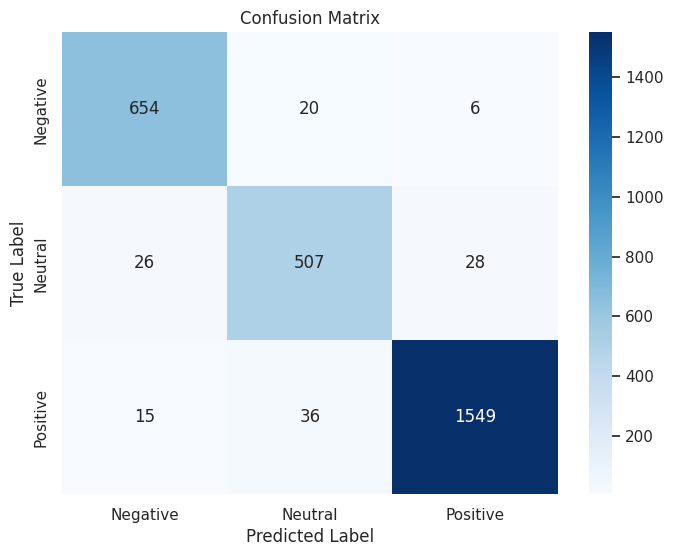

              precision    recall  f1-score   support

    Negative       0.94      0.96      0.95       680
     Neutral       0.90      0.90      0.90       561
    Positive       0.98      0.97      0.97      1600

    accuracy                           0.95      2841
   macro avg       0.94      0.94      0.94      2841
weighted avg       0.95      0.95      0.95      2841



In [21]:

# Get predictions for the validation set
predictions = trainer.predict(tokenized_val)

# Extract predicted labels
predicted_labels = np.argmax(predictions.predictions, axis=1)

# Create confusion matrix
cm = confusion_matrix(tokenized_val['label'], predicted_labels)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print classification report
print(classification_report(tokenized_val['label'], predicted_labels, target_names=['Negative', 'Neutral', 'Positive']))


##saving the model for later use

In [22]:

# Save the best model
best_model_path = "./best_roberta_sentiment_model"
trainer.save_model(best_model_path)
tokenizer.save_pretrained(best_model_path)
print(f"Best model saved to {best_model_path}")


Best model saved to ./best_roberta_sentiment_model


##make predictons

In [23]:

def predict_sentiment(text):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}  # Move inputs to same device

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        prediction = torch.argmax(probs, dim=-1).item()

    sentiment_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
    return sentiment_map[prediction], probs.detach().cpu().numpy()[0]  # Move back to CPU for numpy


# Example predictions
test_reviews = [
    "This product is amazing! I love it so much.",
    "The quality is okay, but not worth the price.",
    "Terrible product. Broke after first use."
]

for review in test_reviews:
    sentiment, probs = predict_sentiment(review)
    print(f"Review: {review}")
    print(f"Sentiment: {sentiment}")
    print(f"Confidence: {max(probs):.4f}")
    print("---")

Review: This product is amazing! I love it so much.
Sentiment: Positive
Confidence: 1.0000
---
Review: The quality is okay, but not worth the price.
Sentiment: Neutral
Confidence: 0.9994
---
Review: Terrible product. Broke after first use.
Sentiment: Negative
Confidence: 1.0000
---
